# Lecture 22 — Inverse Reinforcement Learning (IRL)

**Deep Reinforcement Learning (Sp25)**  
**Instructor:** Dr. Mohammad Hossein Rohban  
**Summary of Lecture 22:** Inverse Reinforcement Learning  
**Summarized By:** Amirhossein Asadi

This notebook implements key concepts from Lecture 22 on Inverse Reinforcement Learning (IRL):

- **RL vs. IRL:** RL learns policies from known rewards; IRL recovers rewards from expert demonstrations.
- **Linear Reward Functions:** Rewards as $r_\psi(s,a) = \psi^\top \phi(s,a)$, where $\phi$ are features.
- **Feature Matching IRL:** Match expected feature counts between expert and learned policies.
- **Maximum Margin IRL:** Ensure expert policy is optimal by a margin, using divergence regularization.
- **Maximum Entropy IRL:** Probabilistic approach maximizing likelihood of expert trajectories under the reward model.

We demonstrate these on a 5x5 GridWorld, recovering a reward function from expert trajectories.

## Part 1 — Setup & Environment

In [8]:
# Standard imports and reproducibility
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from typing import List, Tuple

# Reproducible results
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Plot settings
sns.set(style='whitegrid')

# --- Configuration ---
GRID_SIZE = 5
N_STATES = GRID_SIZE * GRID_SIZE
N_ACTIONS = 4  # Up, Down, Left, Right
GAMMA = 0.9    # Discount factor

# Actions mapping
UP, DOWN, LEFT, RIGHT = 0, 1, 2, 3
ACTIONS = [UP, DOWN, LEFT, RIGHT]
ACTION_NAMES = {0: '↑', 1: '↓', 2: '←', 3: '→'}

In [9]:
class GridWorld:
    def __init__(self, size: int = 5):
        self.size = size
        self.n_states = size * size
        self.goal_state = self.n_states - 1  # bottom-right cell

    def get_next_state(self, state: int, action: int) -> int:
        row, col = divmod(state, self.size)
        if action == UP:
            row = max(row - 1, 0)
        elif action == DOWN:
            row = min(row + 1, self.size - 1)
        elif action == LEFT:
            col = max(col - 1, 0)
        elif action == RIGHT:
            col = min(col + 1, self.size - 1)
        return row * self.size + col

    def get_features(self, state: int) -> np.ndarray:
        # One-hot features for each state
        f = np.zeros(self.n_states)
        f[state] = 1.0
        return f

    def get_transition_probs(self) -> np.ndarray:
        # Deterministic transitions P[s, a, s']
        P = np.zeros((self.n_states, N_ACTIONS, self.n_states))
        for s in range(self.n_states):
            for a in ACTIONS:
                next_s = self.get_next_state(s, a)
                P[s, a, next_s] = 1.0
        return P


env = GridWorld(GRID_SIZE)
print(f"GridWorld {GRID_SIZE}x{GRID_SIZE} initialized with {env.n_states} states.")

GridWorld 5x5 initialized with 25 states.


## Part 2 — The Expert (Value Iteration)

Expert training complete.


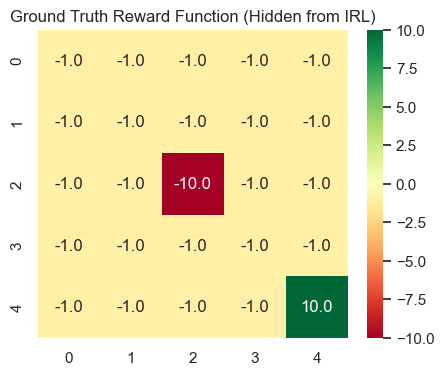

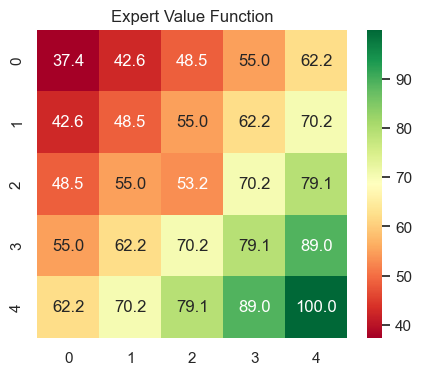

In [10]:
def value_iteration(env: GridWorld, reward_vector: np.ndarray, theta: float = 1e-6) -> Tuple[np.ndarray, np.ndarray]:
    """Return (policy, V) for the given reward vector using value iteration."""
    V = np.zeros(env.n_states)
    P = env.get_transition_probs()

    while True:
        delta = 0.0
        for s in range(env.n_states):
            v = V[s]
            q_values = np.zeros(N_ACTIONS)
            for a in ACTIONS:
                q_values[a] = reward_vector[s] + GAMMA * np.dot(P[s, a], V)
            V[s] = np.max(q_values)
            delta = max(delta, abs(v - V[s]))
        if delta < theta:
            break

    # Deterministic greedy policy
    policy = np.zeros(env.n_states, dtype=int)
    for s in range(env.n_states):
        q_values = np.zeros(N_ACTIONS)
        for a in ACTIONS:
            q_values[a] = reward_vector[s] + GAMMA * np.dot(P[s, a], V)
        policy[s] = np.argmax(q_values)

    return policy, V


# Ground truth reward: -1 step cost, +10 at goal, -10 at a puddle in the middle
ground_truth_rewards = np.full(env.n_states, -1.0)
ground_truth_rewards[env.goal_state] = 10.0
puddle_state = 12  # central cell in 5x5
ground_truth_rewards[puddle_state] = -10.0

expert_policy, expert_values = value_iteration(env, ground_truth_rewards)

# Visualization helper

def plot_grid(values: np.ndarray, title: str = "Grid", cmap: str = "RdYlGn", fmt: str = ".1f"):
    grid = values.reshape((GRID_SIZE, GRID_SIZE))
    plt.figure(figsize=(5, 4))
    sns.heatmap(grid, annot=True, fmt=fmt, cmap=cmap, cbar=True)
    plt.title(title)
    plt.show()

print("Expert training complete.")
plot_grid(ground_truth_rewards, "Ground Truth Reward Function (Hidden from IRL)")
plot_grid(expert_values, "Expert Value Function")

## Part 3 — Generating Expert Demonstrations

In [11]:
def generate_trajectories(env: GridWorld, policy: np.ndarray, n_trajectories: int = 50, max_steps: int = 20) -> List[List[int]]:
    trajectories = []
    for _ in range(n_trajectories):
        start_state = np.random.randint(0, env.n_states - 1)  # avoid starting at goal
        traj = []
        state = start_state
        for _ in range(max_steps):
            traj.append(state)
            if state == env.goal_state:
                break
            action = policy[state]
            state = env.get_next_state(state, action)
        trajectories.append(traj)
    return trajectories

expert_trajs = generate_trajectories(env, expert_policy, n_trajectories=80, max_steps=20)
print(f"Generated {len(expert_trajs)} expert trajectories. Sample: {expert_trajs[0]}")

Generated 80 expert trajectories. Sample: [6, 11, 16, 21, 22, 23, 24]


## Part 4 — Maximum Entropy IRL

Maximum Entropy IRL recovers the reward by maximizing the likelihood of expert trajectories under a probabilistic model:

$$p(\tau | O_{1:T}) \propto p(\tau) \exp\left(\sum_t r_\psi(s_t, a_t)\right)$$

The log-likelihood is:

$$L(\psi) = \frac{1}{N} \sum_i \left[ r_\psi(\tau_i) - \log Z \right]$$

where $Z = \int p(\tau) \exp(r_\psi(\tau)) d\tau$.

The gradient is:

$$\nabla_\psi L = \mathbb{E}_{\tau \sim \pi^*} [\nabla_\psi r_\psi(\tau)] - \mathbb{E}_{\tau \sim p(\tau | O, \psi)} [\nabla_\psi r_\psi(\tau)]$$

Assuming linear rewards $r_\psi(s,a) = \psi^\top \phi(s,a)$, and $\phi(s,a) = \phi(s)$ (state features), we implement gradient ascent by sampling trajectories from the current policy.

In [12]:
def max_ent_irl(env: GridWorld, expert_trajs: List[List[int]], lr: float = 0.01, n_iters: int = 100, n_samples: int = 50):
    """
    Maximum Entropy IRL: Maximize likelihood of expert trajectories.
    Returns recovered weights theta and loss history (negative log-likelihood).
    """
    # Initialize weights
    theta = np.random.uniform(low=-0.1, high=0.1, size=env.n_states)
    
    loss_history = []
    
    for it in range(n_iters):
        # Current reward: r(s,a) = theta . phi(s) (since phi(s,a) = phi(s))
        rewards = theta.copy()
        
        # Solve MDP to get policy from current rewards
        policy, _ = value_iteration(env, rewards)
        
        # Sample trajectories from current policy
        sampled_trajs = generate_trajectories(env, policy, n_trajectories=n_samples, max_steps=20)
        
        # Compute E_expert [sum phi(s,a)]
        expert_grad = np.zeros(env.n_states)
        for traj in expert_trajs:
            for s in traj:
                expert_grad += env.get_features(s)
        expert_grad /= len(expert_trajs)
        
        # Compute E_learned [sum phi(s,a)]
        learned_grad = np.zeros(env.n_states)
        for traj in sampled_trajs:
            for s in traj:
                learned_grad += env.get_features(s)
        learned_grad /= len(sampled_trajs)
        
        # Gradient of log-likelihood
        gradient = expert_grad - learned_grad
        
        # Update weights (gradient ascent)
        theta += lr * gradient
        
        # Compute approximate log-likelihood (for monitoring)
        # L ≈ 1/N sum [r_psi(tau_i) - log Z_approx]
        # Approximate Z by average exp(r) over sampled trajs
        expert_r_sum = np.mean([sum(rewards[s] for s in traj) for traj in expert_trajs])
        learned_r_sum = np.mean([sum(rewards[s] for s in traj) for traj in sampled_trajs])
        log_Z_approx = learned_r_sum + np.log(len(sampled_trajs))  # rough approximation
        loss = - (expert_r_sum - log_Z_approx)  # negative log-likelihood
        loss_history.append(loss)
        
        if (it + 1) % 10 == 0 or it == 0:
            print(f"Iter {it+1}/{n_iters} — Loss: {loss:.4f}")
    
    return theta, loss_history

In [14]:
# Run IRL
print("Running MaxEnt IRL (this may take a few seconds)...")
recovered_weights, loss_history = max_ent_irl(env, expert_trajs, lr=0.05, n_iters=1000, n_samples=500)
recovered_rewards = recovered_weights.copy()
print("IRL finished.")

Running MaxEnt IRL (this may take a few seconds)...
Iter 1/1000 — Loss: 5.5072
Iter 10/1000 — Loss: 3.9770
Iter 20/1000 — Loss: 3.9267
Iter 30/1000 — Loss: 3.9474
Iter 40/1000 — Loss: 4.0175
Iter 50/1000 — Loss: 3.8950
Iter 60/1000 — Loss: 3.8713
Iter 70/1000 — Loss: 3.8317
Iter 80/1000 — Loss: 3.9138
Iter 90/1000 — Loss: 3.9113
Iter 100/1000 — Loss: 3.8630
Iter 110/1000 — Loss: 3.8943
Iter 120/1000 — Loss: 3.8831
Iter 130/1000 — Loss: 3.8465
Iter 140/1000 — Loss: 3.8956
Iter 150/1000 — Loss: 3.8737
Iter 160/1000 — Loss: 3.8928
Iter 170/1000 — Loss: 3.8414
Iter 180/1000 — Loss: 3.8546
Iter 190/1000 — Loss: 3.8563
Iter 200/1000 — Loss: 3.8701
Iter 210/1000 — Loss: 3.8431
Iter 220/1000 — Loss: 3.8502
Iter 230/1000 — Loss: 3.8369
Iter 240/1000 — Loss: 3.8356
Iter 250/1000 — Loss: 4.6507
Iter 260/1000 — Loss: 3.8385
Iter 270/1000 — Loss: 3.8129
Iter 280/1000 — Loss: 3.8938
Iter 290/1000 — Loss: 3.7655
Iter 300/1000 — Loss: 3.7904
Iter 310/1000 — Loss: 3.7838
Iter 320/1000 — Loss: 3.8269
It

## Part 5 — Analysis & Visualization

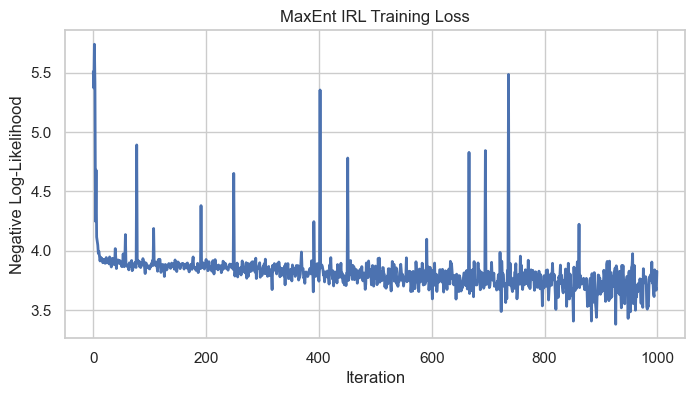

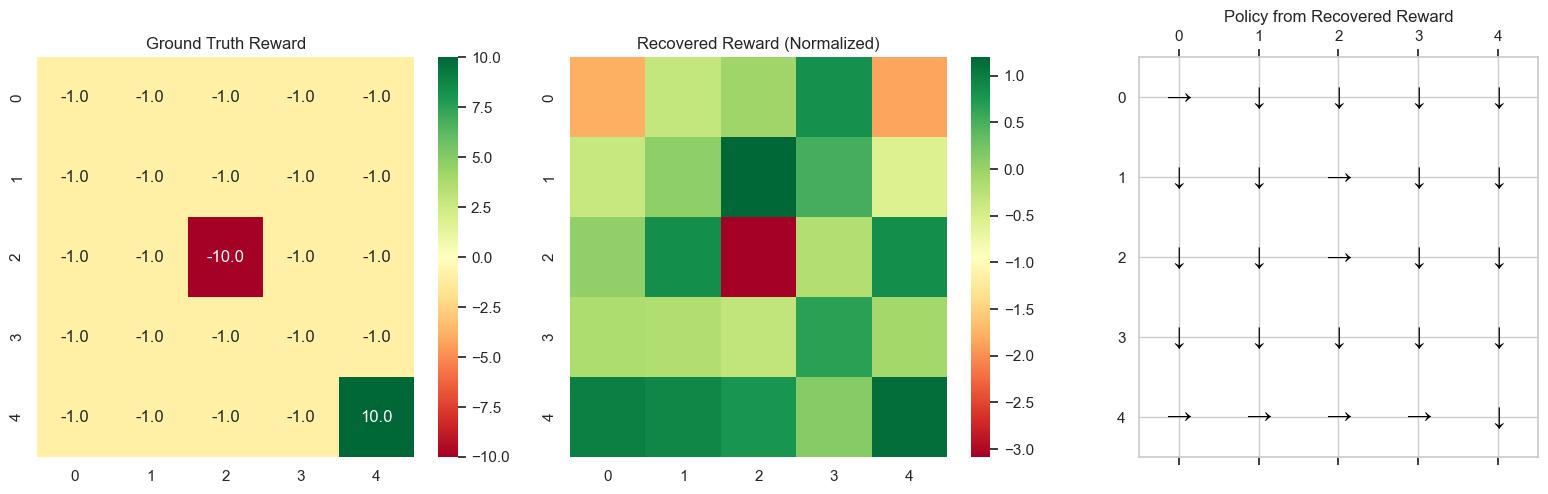

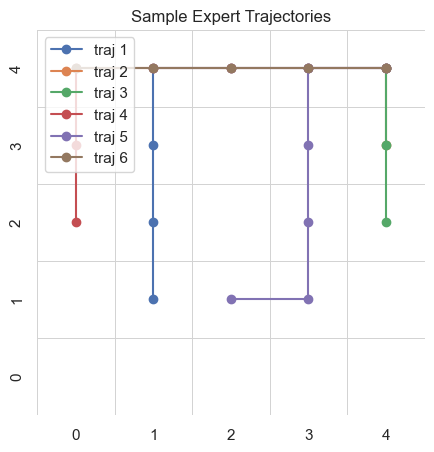

In [16]:
# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(loss_history, lw=2)
plt.xlabel('Iteration')
plt.ylabel('Negative Log-Likelihood')
plt.title('MaxEnt IRL Training Loss')
plt.grid(True)
plt.show()

# Compare Ground Truth vs Recovered
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) Ground Truth
grid_gt = ground_truth_rewards.reshape((GRID_SIZE, GRID_SIZE))
sns.heatmap(grid_gt, ax=axes[0], annot=True, fmt='.1f', cmap='RdYlGn')
axes[0].set_title('Ground Truth Reward')

# 2) Recovered Reward (Normalized for display)
rec_norm = (recovered_rewards - np.mean(recovered_rewards)) / (np.std(recovered_rewards) + 1e-8)
grid_rec = rec_norm.reshape((GRID_SIZE, GRID_SIZE))
sns.heatmap(grid_rec, ax=axes[1], annot=False, cmap='RdYlGn')
axes[1].set_title('Recovered Reward (Normalized)')

# 3) Policy from Recovered Reward
new_policy, _ = value_iteration(env, recovered_rewards)
policy_grid = new_policy.reshape((GRID_SIZE, GRID_SIZE))

axes[2].matshow(np.zeros((GRID_SIZE, GRID_SIZE)), cmap='Greys')
for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        action = policy_grid[i, j]
        txt = ACTION_NAMES.get(action, '?')
        axes[2].text(j, i, txt, ha='center', va='center', fontsize=18, color='black')
axes[2].set_title('Policy from Recovered Reward')

plt.tight_layout()
plt.show()

# Visualize a few expert trajectories on top of the grid
plt.figure(figsize=(5, 5))
G = np.zeros((GRID_SIZE, GRID_SIZE))
ax = sns.heatmap(G, cmap='Greys', cbar=False, linecolor='lightgray', linewidths=0.5)
for k in range(6):
    traj = expert_trajs[k]
    coords = [(s % GRID_SIZE, s // GRID_SIZE) for s in traj]
    xs = [c[0] + 0.5 for c in coords]
    ys = [c[1] + 0.5 for c in coords]
    plt.plot(xs, ys, marker='o', label=f'traj {k+1}')

plt.gca().invert_yaxis()
plt.title('Sample Expert Trajectories')
plt.legend(loc='upper left')
plt.show()

## Interpretation & Notes

- IRL recovers structure of the reward function (high at the goal, low at the puddle) but not the exact scale — this is expected.
- The recovered policy should be qualitatively similar to the expert's behavior.

If you want, I can run the notebook end-to-end and fix any runtime issues, or add: 
- richer feature sets (coordinates, distances),
- more robust MaxEnt implementations (exact forward-backward soft value iteration), or
- code to save and load recovered rewards.